<a href="https://colab.research.google.com/github/Whydoinneedone/09558---Reinforcement-Learning/blob/main/Automated_Portfolio_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
#  PPO Stock Trading Agent  |  Google Colab Notebook
#  Implements: PPO (PyTorch) · Technical Indicators With a Buy & Hold Baseline
# ============================================================
# %% CELL 1 — Install Dependencies
#============================================================
!pip install yfinance ta torch --quiet


In [ ]:
 # %% CELL 2 — Imports
# ============================================================
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import yfinance as yf

# 'ta' is the technical analysis library
from ta.momentum import RSIIndicator
from ta.trend import MACD, SMAIndicator
from ta.volatility import BollingerBands

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")




Device: cpu


In [ ]:
 # %% CELL 3 — Configuration  (edit these to experiment)
# ============================================================
class Config:
    # ── Data ─────────────────────────
    TICKER       = 'AAPL'          # Any Yahoo Finance ticker
    START_DATE   = '2015-01-01'
    END_DATE     = '2025-12-31'
    TRAIN_RATIO  = 0.80            # X % train / 1-X % test

    # ── Environment ─────────────────────────
    INITIAL_BALANCE  = 10_000.0   # Starting cash ($)
    TRANSACTION_COST = 0.001      # 0.1 % per trade (each side)

    # ── PPO Hyperparameters ──────────────────────
    HIDDEN_DIM    = 128            # Neurons per shared layer
    LEARNING_RATE = 3e-4
    GAMMA         = 0.99           # Discount factor
    GAE_LAMBDA    = 0.95           # GAE trace-decay
    CLIP_EPSILON  = 0.1            # PPO clip ratio
    ENTROPY_COEF  = 0.05           # Exploration bonus weight
    VALUE_COEF    = 0.5            # Critic loss weight
    MAX_GRAD_NORM = 0.5            # Gradient clipping
    PPO_EPOCHS    = 4             # Update passes per rollout
    BATCH_SIZE    = 64             # Mini-batch size

    # ── Training ─────────────────────────
    NUM_EPISODES  = 300
    LOG_INTERVAL  = 10             # Print every N episodes

cfg = Config()

In [ ]:
# %% CELL 4 — Data Download & Feature Engineering
# ============================================================

def download_data(ticker: str, start: str, end: str) -> pd.DataFrame:
    """Download OHLCV data from Yahoo Finance."""
    df = yf.download(ticker, start=start, end=end, auto_adjust=True, progress=False)

    # yfinance sometimes returns a MultiIndex — flatten it
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
    print(f"Downloaded {len(df)} trading days for {ticker}  "
          f"({df.index[0].date()} → {df.index[-1].date()})")
    return df


def add_features(df: pd.DataFrame) -> tuple[pd.DataFrame, list[str]]:
    """
    Compute technical indicators and return (enriched_df, feature_col_names).

    All features are either already bounded (RSI, BB %), ratio-based
    (SMA ratios), or normalized by their own std (MACD family) so that
    the neural network receives inputs of similar magnitude.
    """
    close  = df['Close']
    volume = df['Volume']

    # ── Returns ──────────────────────────────────────────────
    df['ret_1d']  = close.pct_change(1)
    df['ret_5d']  = close.pct_change(5)
    df['ret_20d'] = close.pct_change(20)

    # ── Moving-average ratios  (price / MA  −  1) ────────────
    sma20 = SMAIndicator(close, window=20).sma_indicator()
    sma50 = SMAIndicator(close, window=50).sma_indicator()
    df['sma20_ratio'] = (close / sma20) - 1
    df['sma50_ratio'] = (close / sma50) - 1

    # ── Momentum ─────────────────────────────────────────────
    df['rsi'] = RSIIndicator(close, window=14).rsi() / 100.0  # → [0, 1]

    # ── Trend ────────────────────────────────────────────────
    macd_obj = MACD(close)
    df['macd']        = macd_obj.macd()
    df['macd_signal'] = macd_obj.macd_signal()
    df['macd_diff']   = macd_obj.macd_diff()

    # ── Volatility ───────────────────────────────────────────
    bb = BollingerBands(close, window=20)
    df['bb_pct'] = bb.bollinger_pband()  # 0 = lower band, 1 = upper band

    # ── Volume ───────────────────────────────────────────────
    df['vol_ratio'] = volume / volume.rolling(20).mean()

    df = df.dropna().copy()

    FEATURE_COLS = [
        'ret_1d', 'ret_5d', 'ret_20d',
        'sma20_ratio', 'sma50_ratio',
        'rsi', 'macd', 'macd_signal', 'macd_diff',
        'bb_pct', 'vol_ratio',
    ]
    return df, FEATURE_COLS


def normalize_features(train_df: pd.DataFrame,
                        test_df:  pd.DataFrame,
                        feature_cols: list[str]):
    """
    Z-score normalize using TRAINING statistics only (no data leakage).
    MACD values are in price units so they need this; other cols are
    already dimensionless but normalization doesn't hurt.
    Clip to ±3σ to suppress outlier spikes.
    """
    stats = {}
    for col in feature_cols:
        mu  = train_df[col].mean()
        std = train_df[col].std() + 1e-8
        stats[col] = (mu, std)
        train_df[col] = ((train_df[col] - mu) / std).clip(-3, 3)
        test_df[col]  = ((test_df[col]  - mu) / std).clip(-3, 3)
    return train_df, test_df, stats


def prepare_data(cfg: Config):
    df, feature_cols = add_features(download_data(cfg.TICKER, cfg.START_DATE, cfg.END_DATE))

    split = int(len(df) * cfg.TRAIN_RATIO)
    train_df = df.iloc[:split].reset_index(drop=False)   # keep Date column
    test_df  = df.iloc[split:].reset_index(drop=False)

    train_df, test_df, _ = normalize_features(train_df, test_df, feature_cols)

    print(f"Train: {len(train_df)} days  |  Test: {len(test_df)} days")
    return train_df, test_df, feature_cols

train_df, test_df, FEATURE_COLS = prepare_data(cfg)

STATE_DIM  = len(FEATURE_COLS) + 2   # market features + {position, portfolio_ratio}
ACTION_DIM = 3                        # 0=Hold  1=Buy  2=Sell
print(f"State dim: {STATE_DIM}  |  Action dim: {ACTION_DIM}")




Downloaded 2765 trading days for AAPL  (2015-01-02 → 2025-12-30)
Train: 2172 days  |  Test: 544 days
State dim: 13  |  Action dim: 3


In [ ]:
# %% CELL 5 — Trading Environment
# ============================================================

class TradingEnv:
    """
    Single-asset discrete-action trading environment.

    ── Actions ──────────────────────────────────────────────
      0 = Hold  — do nothing
      1 = Buy   — invest ALL available cash at current close price
      2 = Sell  — liquidate ENTIRE position at current close price

    Attempting to Buy while already invested, or Sell while flat,
    is treated as a Hold (no-op) so the agent is never punished for
    an action it cannot execute.

    ── State ────────────────────────────────────────────────
      [11 market features, current_position (0/1), portfolio_ratio]

    ── Reward ───────────────────────────────────────────────
      Δ portfolio_value / portfolio_value_{t-1}
      Transaction costs are physically deducted from the portfolio
      (not added as a separate penalty), so they naturally reduce
      the reward signal whenever a trade occurs.
    """

    HOLD = 0;  BUY = 1;  SELL = 2

    def __init__(self, df, feature_cols,
                 initial_balance=10_000.0,
                 transaction_cost=0.001):
        self.df               = df
        self.feature_cols     = feature_cols
        self.initial_balance  = initial_balance
        self.transaction_cost = transaction_cost
        self.n_steps          = len(df)
        self.reset()

    # ── Public API ───────────────────────────────────────────

    def reset(self):
        self.step_idx           = 0
        self.cash               = self.initial_balance
        self.shares             = 0.0
        self.prev_value         = self.initial_balance
        self.trade_log          = []       # list of (step, 'BUY'/'SELL', price, portfolio_value)
        return self._state()

    def step(self, action: int):
        price = float(self.df['Close'].iloc[self.step_idx])

        # ── Execute trade ────────────────────────────────────
        if action == self.BUY and self.cash > 1.0:
            # Buy as many shares as possible; deduct fee from cash
            gross       = self.cash
            fee         = gross * self.transaction_cost
            self.shares = (gross - fee) / price
            self.cash   = 0.0
            self.trade_log.append((self.step_idx, 'BUY', price, self._portfolio(price)))

        elif action == self.SELL and self.shares > 0.0:
            # Sell all shares; deduct fee from proceeds
            gross      = self.shares * price
            fee        = gross * self.transaction_cost
            self.cash  = gross - fee
            self.shares = 0.0
            self.trade_log.append((self.step_idx, 'SELL', price, self._portfolio(price)))

        # ── Advance time ─────────────────────────────────────
        self.step_idx += 1
        done = self.step_idx >= self.n_steps - 1

       # Value at the NEW price
        new_price    = float(self.df['Close'].iloc[self.step_idx])
        new_value    = self._portfolio(new_price)

        # Agent's return
        agent_return = (new_value - self.prev_value) / (self.prev_value + 1e-8)

        # Market's return (Buy & Hold baseline for this step)
        market_return = (new_price - price) / (price + 1e-8)

        # Reward: How much better did the agent do than simply holding?
        reward = agent_return - market_return

        self.prev_value = new_value

        info = dict(portfolio_value=new_value,
                    shares=self.shares, cash=self.cash,
                    step=self.step_idx)

        return self._state(), reward, done, info

    # ── Helpers ──────────────────────────────────────────────

    def _portfolio(self, price=None):
        if price is None:
            price = float(self.df['Close'].iloc[self.step_idx])
        return self.cash + self.shares * price

    def _state(self):
        feats   = self.df[self.feature_cols].iloc[self.step_idx].values.astype(np.float32)
        pos     = np.float32(1.0 if self.shares > 0 else 0.0)
        p_ratio = np.float32(self._portfolio() / self.initial_balance)
        return np.append(feats, [pos, p_ratio])

    def buy_and_hold_curve(self):
        """Return array of portfolio values for a simple Buy & Hold strategy."""
        prices = self.df['Close'].values.astype(float)
        shares = self.initial_balance / prices[0]
        return shares * prices

    def buy_and_hold_final(self):
        curve    = self.buy_and_hold_curve()
        final    = curve[-1]
        ret_pct  = (final - self.initial_balance) / self.initial_balance * 100
        return final, ret_pct




In [ ]:
# %% CELL 6 — Actor-Critic Network
# ============================================================

class ActorCritic(nn.Module):
    """
    Shared-backbone Actor-Critic used by PPO.

    Architecture
    ────────────
      Input (state_dim)
          ↓
      Linear → Tanh  ┐
      Linear → Tanh  ┘  shared feature extractor
          ↓           ↓
      Actor head    Critic head
      (action_dim)  (scalar value)

    Why shared?  The features useful for deciding WHAT to do are largely
    the same as those needed to estimate HOW GOOD the current state is,
    so sharing saves parameters and stabilises learning.
    """

    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 32):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(state_dim,  hidden_dim), nn.Tanh(),
            nn.Dropout(0.2), # <-- Add dropout to prevent overfitting
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
        )
        self.actor  = nn.Linear(hidden_dim, action_dim)   # → logits
        self.critic = nn.Linear(hidden_dim, 1)             # → V(s)

        # Orthogonal init (standard for PPO — keeps gradient scale healthy)
        for layer in self.shared:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.zeros_(layer.bias)
        nn.init.orthogonal_(self.actor.weight,  gain=0.01)
        nn.init.zeros_(self.actor.bias)
        nn.init.orthogonal_(self.critic.weight, gain=1.0)
        nn.init.zeros_(self.critic.bias)

    def forward(self, x):
        h      = self.shared(x)
        logits = self.actor(h)
        value  = self.critic(h).squeeze(-1)
        return logits, value

    def get_action_and_value(self, state: torch.Tensor,
                              action: torch.Tensor = None):
        """
        Sample (or evaluate) an action and return associated quantities.

        Returns: action, log_prob, entropy, value
        """
        logits, value = self.forward(state)
        dist          = Categorical(logits=logits)
        if action is None:
            action = dist.sample()
        return action, dist.log_prob(action), dist.entropy(), value




In [ ]:
# %% CELL 7 — Rollout Buffer
# ============================================================

class RolloutBuffer:
    """
    Stores one full episode of transitions.
    After the episode ends, compute_gae() calculates the advantage
    estimates needed for the PPO update, then the buffer is cleared.
    """

    def __init__(self):
        self.states    = []
        self.actions   = []
        self.log_probs = []
        self.rewards   = []
        self.values    = []
        self.dones     = []

    def add(self, state, action, log_prob, reward, value, done):
        self.states.append(state)
        self.actions.append(action)
        self.log_probs.append(log_prob)
        self.rewards.append(reward)
        self.values.append(value)
        self.dones.append(done)

    def compute_gae(self, last_value: float, gamma: float, lam: float):
        """
        Generalised Advantage Estimation (GAE-λ).

        GAE smoothly interpolates between:
          λ=0  →  TD(0) advantage  (low variance, high bias)
          λ=1  →  Monte-Carlo      (high variance, low bias)

        δ_t = r_t + γ·V(s_{t+1}) - V(s_t)
        A_t = δ_t + (γλ)·δ_{t+1} + (γλ)²·δ_{t+2} + …
        """
        T          = len(self.rewards)
        advantages = np.zeros(T, dtype=np.float32)
        gae        = 0.0

        for t in reversed(range(T)):
            mask       = 1.0 - float(self.dones[t])
            next_val   = self.values[t + 1] if t < T - 1 else last_value
            delta      = self.rewards[t] + gamma * next_val * mask - self.values[t]
            gae        = delta + gamma * lam * mask * gae
            advantages[t] = gae

        returns = advantages + np.array(self.values, dtype=np.float32)
        return returns, advantages

    def to_tensors(self, dev):
        return (
            torch.tensor(np.array(self.states),    dtype=torch.float32).to(dev),
            torch.tensor(np.array(self.actions),   dtype=torch.long   ).to(dev),
            torch.tensor(np.array(self.log_probs), dtype=torch.float32).to(dev),
            torch.tensor(np.array(self.values),    dtype=torch.float32).to(dev),
        )

    def clear(self):
        self.__init__()

    def __len__(self):
        return len(self.rewards)




In [ ]:
# %% CELL 8 — PPO Agent
# ============================================================

class PPOAgent:
    """
    Proximal Policy Optimisation.

    Core idea
    ─────────
    Vanilla policy gradient takes ONE gradient step per batch.
    PPO reuses the same rollout for K epochs, but clips the importance-
    weight ratio r_t(θ) = π_θ(a|s) / π_θ_old(a|s) to [1-ε, 1+ε].
    This prevents a single bad update from collapsing the policy.

    Loss = L_CLIP − c₁·L_value + c₂·H[π]
      • L_CLIP  — clipped surrogate (actor objective)
      • L_value — MSE between V(s) and observed returns (critic)
      • H[π]    — policy entropy (exploration bonus)
    """

    def __init__(self, state_dim: int, action_dim: int, cfg: Config, dev):
        self.cfg    = cfg
        self.device = dev
        self.policy = ActorCritic(state_dim, action_dim, cfg.HIDDEN_DIM).to(dev)
        self.opt    = optim.Adam(self.policy.parameters(),
                                 lr=cfg.LEARNING_RATE, eps=1e-5)
        self.buffer = RolloutBuffer()

    # ── Interaction ──────────────────────────────────────────

    @torch.no_grad()
    def act(self, state: np.ndarray):
        """Sample an action stochastically (used during training)."""
        s      = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        a, lp, _, v = self.policy.get_action_and_value(s)
        return a.item(), lp.item(), v.item()

    @torch.no_grad()
    def act_greedy(self, state: np.ndarray):
        """Take the most probable action (used during evaluation)."""
        s           = torch.tensor(state, dtype=torch.float32).unsqueeze(0).to(self.device)
        logits, _   = self.policy(s)
        return logits.argmax(dim=-1).item()

    # ── Learning ─────────────────────────────────────────────

    def update(self, last_value: float) -> dict:
        """Run PPO_EPOCHS mini-batch updates on the current rollout buffer."""
        cfg = self.cfg
        returns, advantages = self.buffer.compute_gae(last_value, cfg.GAMMA, cfg.GAE_LAMBDA)

        # Normalise advantages — reduces variance without changing the
        # direction of the gradient update
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        states, actions, old_lp, old_vals = self.buffer.to_tensors(self.device)
        ret_t  = torch.tensor(returns,    dtype=torch.float32).to(self.device)
        adv_t  = torch.tensor(advantages, dtype=torch.float32).to(self.device)

        T       = len(self.buffer)
        idx_all = np.arange(T)
        p_losses, v_losses, entropies = [], [], []

        for _ in range(cfg.PPO_EPOCHS):
            np.random.shuffle(idx_all)

            for start in range(0, T, cfg.BATCH_SIZE):
                b = torch.tensor(idx_all[start:start + cfg.BATCH_SIZE],
                                 dtype=torch.long).to(self.device)

                _, new_lp, ent, new_vals = self.policy.get_action_and_value(
                    states[b], actions[b])

                # ── Actor loss (clipped surrogate) ────────────
                ratio  = torch.exp(new_lp - old_lp[b])
                adv_b  = adv_t[b]
                surr1  = ratio * adv_b
                surr2  = torch.clamp(ratio,
                                     1 - cfg.CLIP_EPSILON,
                                     1 + cfg.CLIP_EPSILON) * adv_b
                L_clip = -torch.min(surr1, surr2).mean()

                # ── Critic loss (clipped value loss) ──────────
                # Clip the value update to prevent the critic from
                # making large jumps in a single update step
                v_clipped = old_vals[b] + torch.clamp(
                    new_vals - old_vals[b],
                    -cfg.CLIP_EPSILON, cfg.CLIP_EPSILON)
                L_value = torch.max(
                    nn.functional.mse_loss(new_vals,   ret_t[b]),
                    nn.functional.mse_loss(v_clipped,  ret_t[b])
                )

                # ── Entropy bonus ─────────────────────────────
                L_ent = -ent.mean()

                loss = L_clip + cfg.VALUE_COEF * L_value + cfg.ENTROPY_COEF * L_ent

                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.policy.parameters(), cfg.MAX_GRAD_NORM)
                self.opt.step()

                p_losses.append(L_clip.item())
                v_losses.append(L_value.item())
                entropies.append(ent.mean().item())

        self.buffer.clear()
        return dict(policy_loss=np.mean(p_losses),
                    value_loss=np.mean(v_losses),
                    entropy=np.mean(entropies))




In [ ]:
# %% CELL 9 — Training Loop
# ============================================================

def train(cfg: Config, train_df: pd.DataFrame,
          feature_cols: list, state_dim: int,
          action_dim: int, dev) -> tuple:

    env   = TradingEnv(train_df, feature_cols,
                       cfg.INITIAL_BALANCE, cfg.TRANSACTION_COST)
    agent = PPOAgent(state_dim, action_dim, cfg, dev)

    ep_rewards, ep_returns, ep_trades = [], [], []
    loss_history = defaultdict(list)

    bh_final, bh_pct = env.buy_and_hold_final()

    print("=" * 65)
    print(f" Training PPO on {cfg.TICKER}  |  {len(train_df)} training days")
    print(f" Episodes: {cfg.NUM_EPISODES}  |  Device: {dev}")
    print(f" Buy & Hold baseline return: {bh_pct:+.1f}%")
    print("=" * 65)

    for ep in range(1, cfg.NUM_EPISODES + 1):
        state    = env.reset()
        done     = False
        ep_reward = 0.0

        # ── Collect one full episode ──────────────────────────
        while not done:
            action, log_prob, value = agent.act(state)
            next_state, reward, done, info = env.step(action)

            agent.buffer.add(state, action, log_prob, reward, value, done)
            state      = next_state
            ep_reward += reward

        # Bootstrap value from the last state (0 if truly terminal)
        last_val = 0.0 if done else agent.act(state)[2]

        # ── PPO update ────────────────────────────────────────
        losses = agent.update(last_val)
        for k, v in losses.items():
            loss_history[k].append(v)

        final_pv  = info['portfolio_value']
        pct_ret   = (final_pv - cfg.INITIAL_BALANCE) / cfg.INITIAL_BALANCE * 100
        n_trades  = len(env.trade_log)

        ep_rewards.append(ep_reward)
        ep_returns.append(pct_ret)
        ep_trades.append(n_trades)

        if ep % cfg.LOG_INTERVAL == 0:
            w = cfg.LOG_INTERVAL
            print(
                f"Ep {ep:4d}/{cfg.NUM_EPISODES} | "
                f"Avg Rwd: {np.mean(ep_rewards[-w:]):+.4f} | "
                f"Avg Ret: {np.mean(ep_returns[-w:]):+.1f}% | "
                f"Trades: {np.mean(ep_trades[-w:]):.0f} | "
                f"π Loss: {losses['policy_loss']:.4f} | "
                f"V Loss: {losses['value_loss']:.4f} | "
                f"Ent: {losses['entropy']:.3f}"
            )

    print("\n✓ Training complete.")
    return agent, dict(
        ep_rewards=ep_rewards,
        ep_returns=ep_returns,
        ep_trades=ep_trades,
        loss_history=dict(loss_history),
        bh_pct=bh_pct,
    )

agent, train_stats = train(cfg, train_df, FEATURE_COLS, STATE_DIM, ACTION_DIM, device)




 Training PPO on AAPL  |  2172 training days
 Episodes: 300  |  Device: cpu
 Buy & Hold baseline return: +498.4%
Ep   10/300 | Avg Rwd: -1.4873 | Avg Ret: +73.5% | Trades: 704 | π Loss: -0.0015 | V Loss: 0.0020 | Ent: 1.085
Ep   20/300 | Avg Rwd: -1.6327 | Avg Ret: +44.2% | Trades: 670 | π Loss: -0.0019 | V Loss: 0.0016 | Ent: 1.082
Ep   30/300 | Avg Rwd: -1.3283 | Avg Ret: +99.0% | Trades: 618 | π Loss: -0.0010 | V Loss: 0.0016 | Ent: 1.075
Ep   40/300 | Avg Rwd: -1.1184 | Avg Ret: +138.2% | Trades: 615 | π Loss: 0.0006 | V Loss: 0.0020 | Ent: 1.066
Ep   50/300 | Avg Rwd: -0.8874 | Avg Ret: +216.9% | Trades: 570 | π Loss: 0.0022 | V Loss: 0.0010 | Ent: 1.045
Ep   60/300 | Avg Rwd: -0.9046 | Avg Ret: +204.4% | Trades: 526 | π Loss: 0.0010 | V Loss: 0.0010 | Ent: 1.022
Ep   70/300 | Avg Rwd: -0.7800 | Avg Ret: +245.4% | Trades: 445 | π Loss: 0.0009 | V Loss: 0.0010 | Ent: 0.987
Ep   80/300 | Avg Rwd: -0.8448 | Avg Ret: +203.1% | Trades: 422 | π Loss: 0.0016 | V Loss: 0.0007 | Ent: 0.974

In [ ]:
# %% CELL 10 — Evaluation  (FIXED)
# ============================================================
# Fixes applied:
#   1. BH baseline is computed from prices[0] to prices[len(pv_curve)-2]
#      so it covers exactly the same days as the PPO episode — no off-by-one.
#   2. Winner check uses a small tolerance (0.01%) to avoid noise flipping
#      the result on near-ties.
#   3. More diagnostic output so you can see WHERE the curves diverge.
#   4. `act_greedy` is now explicitly bounded against index overrun.
# ============================================================

def evaluate(agent: PPOAgent, df: pd.DataFrame,
             feature_cols: list, cfg: Config, label: str = 'Test'):
    """
    Run the trained agent in greedy (deterministic) mode on df.

    Alignment guarantee
    ───────────────────
    The PPO curve is built step-by-step inside the environment.
    The BH curve is reconstructed HERE from the same price slice
    the episode actually traversed, so both curves cover identical
    calendar days and the final-value comparison is always fair.
    """

    env   = TradingEnv(df, feature_cols, cfg.INITIAL_BALANCE, cfg.TRANSACTION_COST)
    state = env.reset()
    done  = False

    pv_curve = [cfg.INITIAL_BALANCE]   # portfolio value at each timestep
    actions  = []                       # action taken at each timestep

    agent.policy.eval()
    with torch.no_grad():
        while not done:
            action               = agent.act_greedy(state)
            state, _, done, info = env.step(action)
            pv_curve.append(info['portfolio_value'])
            actions.append(action)
    agent.policy.train()

    # ── Reconstruct BH curve over the same price slice ───────
    # pv_curve[0]  = value BEFORE step 0   (initial balance)
    # pv_curve[k]  = value AFTER  step k-1 (price index k)
    # So pv_curve has N+1 entries covering prices[0..N].
    # We build BH the same way: invest at prices[0], value at each price.
    prices    = df['Close'].values.astype(float)
    N_steps   = len(pv_curve) - 1        # number of trading days elapsed
    bh_prices = prices[:N_steps + 1]     # prices[0] through prices[N_steps]

    if len(bh_prices) < 2:
        raise ValueError(f"Episode too short ({len(bh_prices)} prices). "
                         "Check your dataframe length.")

    bh_shares = cfg.INITIAL_BALANCE / bh_prices[0]
    bh_curve  = (bh_shares * bh_prices).tolist()  # same length as pv_curve ✓

    # ── Final values and returns ──────────────────────────────
    ppo_final = pv_curve[-1]
    bh_final  = bh_curve[-1]

    ppo_pct   = (ppo_final - cfg.INITIAL_BALANCE) / cfg.INITIAL_BALANCE * 100
    bh_pct    = (bh_final  - cfg.INITIAL_BALANCE) / cfg.INITIAL_BALANCE * 100

    # Tolerance: treat differences < 0.01% as a tie (avoids float noise flips)
    TOLERANCE = 0.01
    diff      = ppo_pct - bh_pct
    if abs(diff) < TOLERANCE:
        winner = "Essentially tied"
    elif diff > 0:
        winner = f"PPO Agent wins  (by {diff:+.2f}%)"
    else:
        winner = f"Buy & Hold wins  (by {-diff:.2f}%)"

    n_trades  = len(env.trade_log)
    action_counts = {
        'Hold': actions.count(0),
        'Buy':  actions.count(1),
        'Sell': actions.count(2),
    }

    # ── Print report ─────────────────────────────────────────
    print(f"\n{'='*65}")
    print(f"  EVALUATION  ({label.upper()})  —  {cfg.TICKER}")
    print(f"{'='*65}")
    print(f"  Start value : ${cfg.INITIAL_BALANCE:>10,.2f}")
    print(f"  PPO Agent   : ${ppo_final:>10,.2f}   return: {ppo_pct:+.2f}%")
    print(f"  Buy & Hold  : ${bh_final:>10,.2f}   return: {bh_pct:+.2f}%")
    print(f"  Difference  :              {diff:>+8.2f}%")
    print(f"  Days traded : {N_steps}")
    print(f"  Trades      : {n_trades}  "
          f"(Hold={action_counts['Hold']}, "
          f"Buy={action_counts['Buy']}, "
          f"Sell={action_counts['Sell']})")
    print(f"  {winner}")
    print(f"{'='*65}\n")

    # Sanity check: curves must be the same length
    assert len(pv_curve) == len(bh_curve), (
        f"Length mismatch: pv_curve={len(pv_curve)}, bh_curve={len(bh_curve)}")

    return dict(
        pv_curve   = pv_curve,
        bh_curve   = bh_curve,
        actions    = actions,
        trade_log  = env.trade_log,
        ppo_pct    = ppo_pct,
        bh_pct     = bh_pct,
        diff_pct   = diff,
        n_trades   = n_trades,
        action_counts = action_counts,
    )


# ── Run both evaluations ──────────────────────────────────────
train_results = evaluate(agent, train_df, FEATURE_COLS, cfg, label='Train')
test_results  = evaluate(agent, test_df,  FEATURE_COLS, cfg, label='Test')


# ── Sanity-check: print first and last values side-by-side ───
# If the winner still looks wrong, these numbers will reveal why.
for label, results in [('Train', train_results), ('Test', test_results)]:
    pv = results['pv_curve']
    bh = results['bh_curve']
    print(f"[{label}] Day 0:   PPO=${pv[0]:,.2f}  BH=${bh[0]:,.2f}")
    print(f"[{label}] Day {len(pv)-1}: PPO=${pv[-1]:,.2f}  BH=${bh[-1]:,.2f}")
    print()




  EVALUATION  (TRAIN)  —  AAPL
  Start value : $ 10,000.00
  PPO Agent   : $184,617.58   return: +1746.18%
  Buy & Hold  : $ 59,844.93   return: +498.45%
  Difference  :              +1247.73%
  Days traded : 2171
  Trades      : 116  (Hold=967, Buy=930, Sell=274)
  PPO Agent wins  (by +1247.73%)


  EVALUATION  (TEST)  —  AAPL
  Start value : $ 10,000.00
  PPO Agent   : $ 13,538.63   return: +35.39%
  Buy & Hold  : $ 16,208.94   return: +62.09%
  Difference  :                -26.70%
  Days traded : 543
  Trades      : 42  (Hold=339, Buy=118, Sell=86)
  Buy & Hold wins  (by 26.70%)

[Train] Day 0:   PPO=$10,000.00  BH=$10,000.00
[Train] Day 2171: PPO=$184,617.58  BH=$59,844.93

[Test] Day 0:   PPO=$10,000.00  BH=$10,000.00
[Test] Day 543: PPO=$13,538.63  BH=$16,208.94



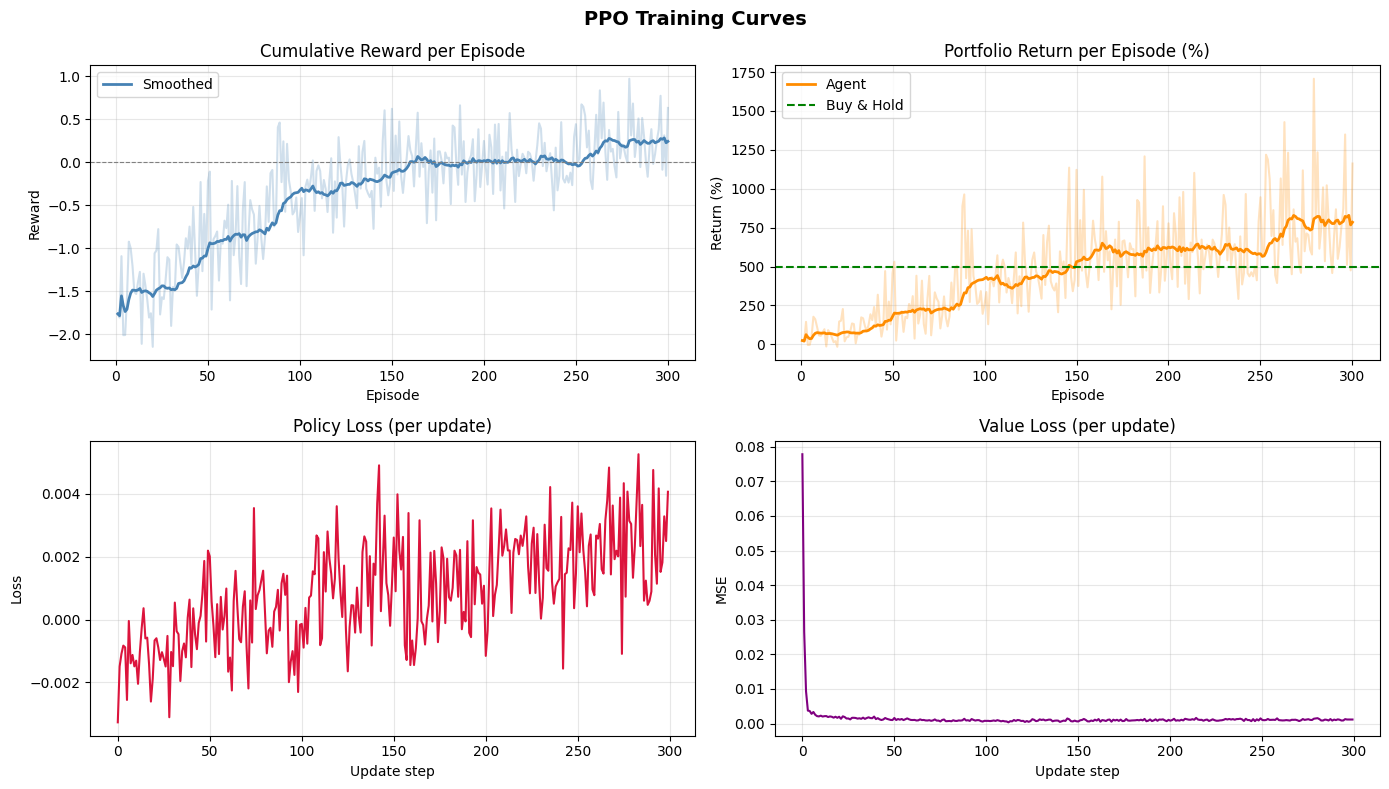

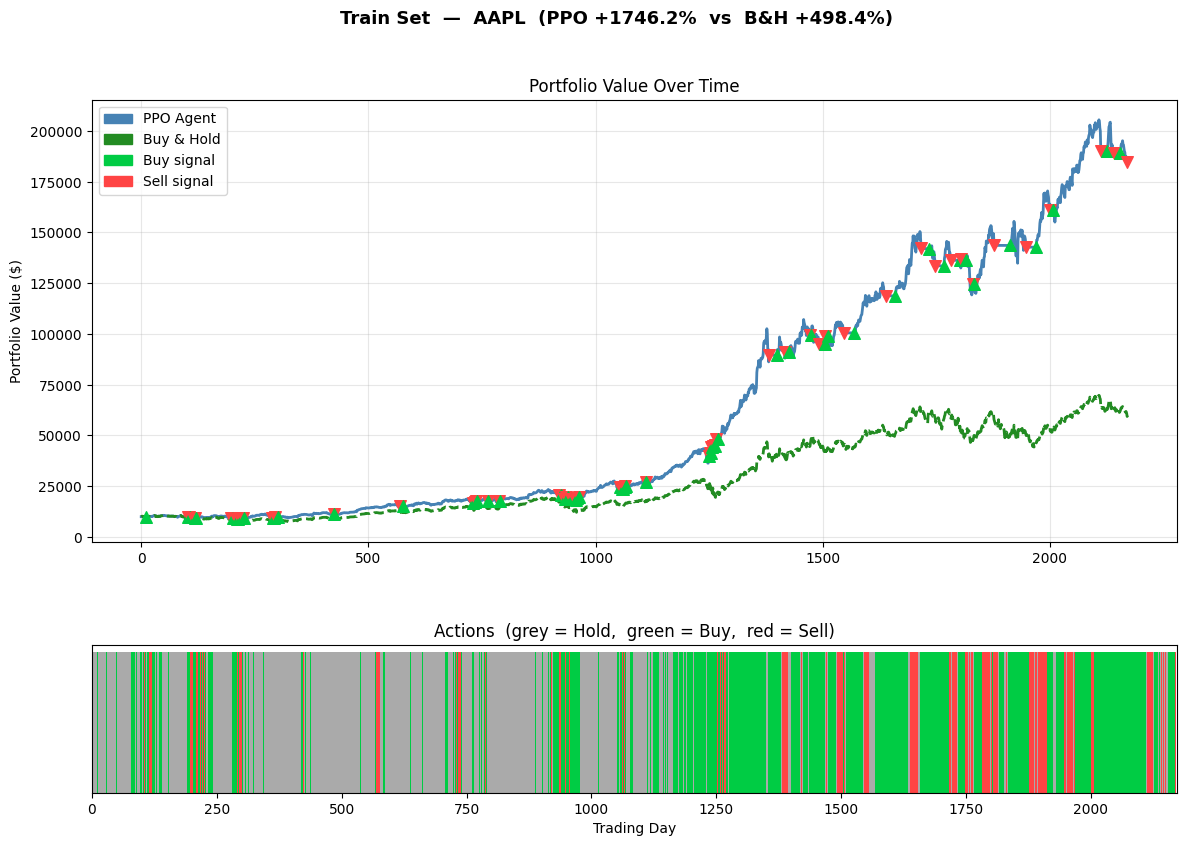

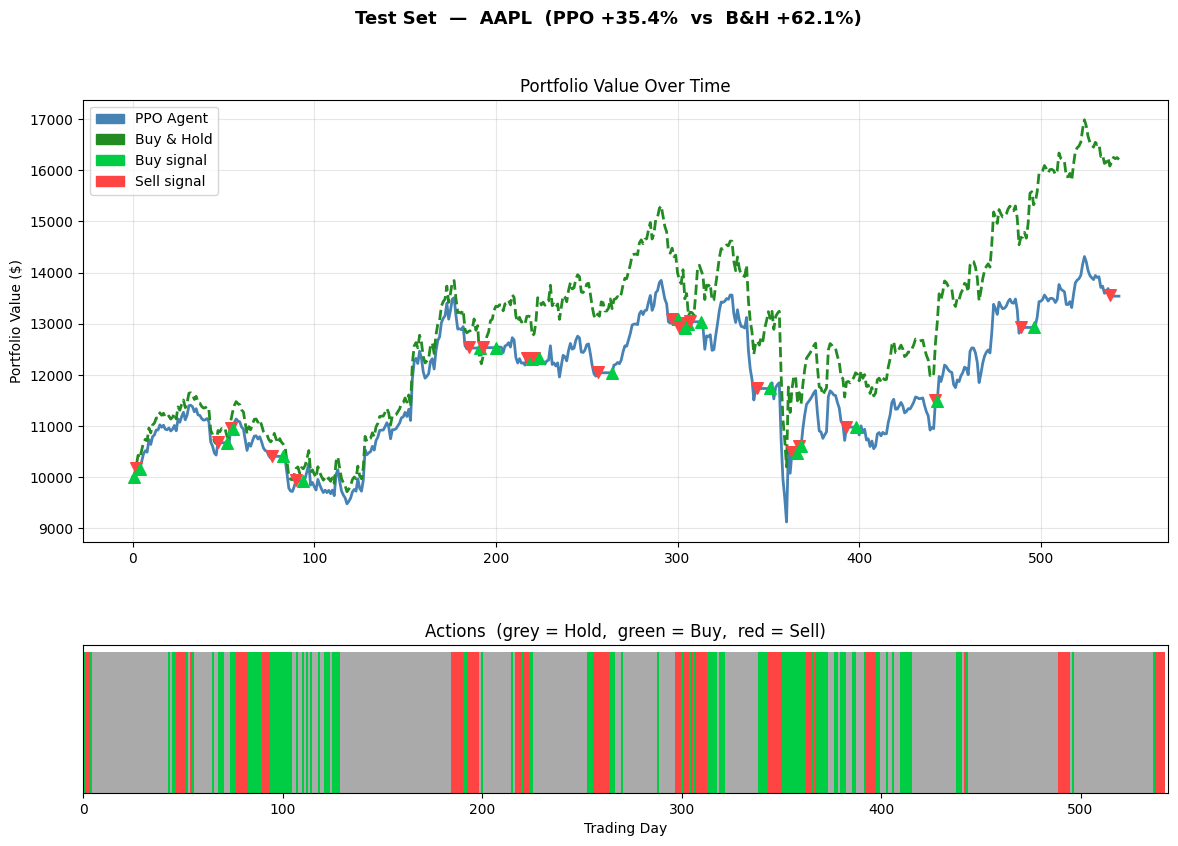

In [ ]:
# %% CELL 11 — Visualisation
# ============================================================

def smooth(x, w=20):
    """Rolling-mean smoothing for noisy training curves."""
    return pd.Series(x).rolling(w, min_periods=1).mean().values


def plot_training_curves(stats: dict):
    """Four-panel view of the training process."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('PPO Training Curves', fontsize=14, fontweight='bold')

    ep = np.arange(1, len(stats['ep_rewards']) + 1)

    # ── Cumulative reward ────────────────────────────────────
    ax = axes[0, 0]
    ax.plot(ep, stats['ep_rewards'], alpha=0.25, color='steelblue')
    ax.plot(ep, smooth(stats['ep_rewards']), color='steelblue', lw=2, label='Smoothed')
    ax.axhline(0, color='gray', ls='--', lw=0.8)
    ax.set_title('Cumulative Reward per Episode')
    ax.set_xlabel('Episode');  ax.set_ylabel('Reward')
    ax.legend();  ax.grid(alpha=0.3)

    # ── Portfolio return % ───────────────────────────────────
    ax = axes[0, 1]
    ax.plot(ep, stats['ep_returns'], alpha=0.25, color='darkorange')
    ax.plot(ep, smooth(stats['ep_returns']), color='darkorange', lw=2, label='Agent')
    ax.axhline(stats['bh_pct'], color='green', ls='--', lw=1.5, label='Buy & Hold')
    ax.set_title('Portfolio Return per Episode (%)')
    ax.set_xlabel('Episode');  ax.set_ylabel('Return (%)')
    ax.legend();  ax.grid(alpha=0.3)

    # ── Policy loss ──────────────────────────────────────────
    ax = axes[1, 0]
    ax.plot(stats['loss_history']['policy_loss'], color='crimson', lw=1.5)
    ax.set_title('Policy Loss (per update)')
    ax.set_xlabel('Update step');  ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)

    # ── Value loss ───────────────────────────────────────────
    ax = axes[1, 1]
    ax.plot(stats['loss_history']['value_loss'], color='purple', lw=1.5)
    ax.set_title('Value Loss (per update)')
    ax.set_xlabel('Update step');  ax.set_ylabel('MSE')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_evaluation(results: dict, df: pd.DataFrame,
                    cfg: Config, label: str = 'Test'):
    """
    Two-panel figure:
      Top   — PPO portfolio value vs Buy & Hold over time
      Bottom — action taken each day (colour-coded)
    """
    fig, axes = plt.subplots(
        2, 1, figsize=(14, 9),
        gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.35}
    )
    fig.suptitle(f'{label} Set  —  {cfg.TICKER}  '
                 f'(PPO {results["ppo_pct"]:+.1f}%  vs  '
                 f'B&H {results["bh_pct"]:+.1f}%)',
                 fontsize=13, fontweight='bold')

    pv  = results['pv_curve']
    bh  = results['bh_curve']
    N   = min(len(pv), len(bh))
    xs  = np.arange(N)

    # ── Portfolio value ───────────────────────────────────────
    ax1 = axes[0]
    ax1.plot(xs, pv[:N],   color='steelblue',  lw=2,   label='PPO Agent')
    ax1.plot(xs, bh[:N],   color='forestgreen', lw=2, ls='--', label='Buy & Hold')

    # Mark trade entry/exit on the portfolio curve
    for step, action, price, pval in results['trade_log']:
        if step < N:
            colour  = '#00cc44' if action == 'BUY' else '#ff4444'
            marker  = '^'       if action == 'BUY' else 'v'
            y_val   = pv[min(step, len(pv) - 1)]
            ax1.scatter(step, y_val, color=colour, marker=marker, s=70, zorder=5)

    ax1.set_ylabel('Portfolio Value ($)')
    ax1.set_title('Portfolio Value Over Time')
    handles = [
        mpatches.Patch(color='steelblue',   label='PPO Agent'),
        mpatches.Patch(color='forestgreen', label='Buy & Hold'),
        mpatches.Patch(color='#00cc44',     label='Buy signal'),
        mpatches.Patch(color='#ff4444',     label='Sell signal'),
    ]
    ax1.legend(handles=handles, loc='upper left')
    ax1.grid(alpha=0.3)

    # ── Action strip ─────────────────────────────────────────
    action_names = {0: 'Hold', 1: 'Buy', 2: 'Sell'}
    action_clrs  = {0: '#aaaaaa', 1: '#00cc44', 2: '#ff4444'}
    acts = results['actions'][:N - 1]

    ax2 = axes[1]
    ax2.bar(np.arange(len(acts)),
            [1] * len(acts),
            color=[action_clrs[a] for a in acts],
            width=1.0)
    ax2.set_xlim(0, N)
    ax2.set_xlabel('Trading Day')
    ax2.set_yticks([])
    ax2.set_title('Actions  (grey = Hold,  green = Buy,  red = Sell)')

    plt.savefig(f'{label.lower()}_evaluation.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_training_curves(train_stats)
plot_evaluation(train_results, train_df, cfg, label='Train')
plot_evaluation(test_results,  test_df,  cfg, label='Test')




In [ ]:
# %% CELL 12 — Save & Load Model  (optional)
# ============================================================

# ── Save ─────────────────────────────────────────────────────
torch.save({
    'policy_state_dict': agent.policy.state_dict(),
    'optimizer_state_dict': agent.opt.state_dict(),
    'config': cfg.__dict__,
    'feature_cols': FEATURE_COLS,
}, 'ppo_trading_agent.pt')
print("Model saved → ppo_trading_agent.pt")

# ── Load (example) ───────────────────────────────────────────
# checkpoint = torch.load('ppo_trading_agent.pt', map_location=device)
# agent.policy.load_state_dict(checkpoint['policy_state_dict'])
# agent.opt.load_state_dict(checkpoint['optimizer_state_dict'])




Model saved → ppo_trading_agent.pt


In [ ]:
# %% CELL 13 — Experiment: Try a Different Ticker
# ============================================================
# Uncomment and edit to quickly run a second experiment

# cfg2 = Config()
# cfg2.TICKER = 'MSFT'          # swap ticker
# cfg2.NUM_EPISODES = 300
#
# train_df2, test_df2, FEAT2 = prepare_data(cfg2)
# STATE_DIM2 = len(FEAT2) + 2
# agent2, stats2 = train(cfg2, train_df2, FEAT2, STATE_DIM2, ACTION_DIM, device)
# results2 = evaluate(agent2, test_df2, FEAT2, cfg2, label='Test')
# plot_evaluation(results2, test_df2, cfg2, label='Test')




In [ ]:
# %% CELL 14 — Quick Summary of Hyperparameters to Tune
# ============================================================
# ┌─────────────────────┬──────────────────────────────────────────────────┐
# │ Hyperparameter      │ What it controls                                 │
# ├─────────────────────┼──────────────────────────────────────────────────┤
# │ CLIP_EPSILON        │ How much the policy can change per update.       │
# │  (default 0.2)      │ Lower → more conservative; higher → faster but  │
# │                     │ less stable.                                     │
# ├─────────────────────┼──────────────────────────────────────────────────┤
# │ ENTROPY_COEF        │ Encourages exploration.  Increase if the agent  │
# │  (default 0.01)     │ gets stuck always Holding or always Buying.     │
# ├─────────────────────┼──────────────────────────────────────────────────┤
# │ GAE_LAMBDA          │ Bias-variance trade-off in advantage estimation. │
# │  (default 0.95)     │ 0 = TD(0), 1 = Monte Carlo.                     │
# ├─────────────────────┼──────────────────────────────────────────────────┤
# │ TRANSACTION_COST    │ Fee per trade.  0.001 = 0.1 %.  Increase to     │
# │  (default 0.001)    │ further penalise over-trading.                  │
# ├─────────────────────┼──────────────────────────────────────────────────┤
# │ NUM_EPISODES        │ More episodes → more training time.  Watch the  │
# │  (default 300)      │ reward curve; stop when it plateaus.            │
# └─────────────────────┴──────────────────────────────────────────────────┘